## 1. Import required libraries

In [1]:
%pip install umap-learn contractions emoji seaborn rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Regular expressions for text cleaning
import re
from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Text cleaning
import contractions
import emoji
from rapidfuzz import fuzz

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Word cloud visualization
from wordcloud import WordCloud, STOPWORDS

# Topic modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Dimensionality reduction for embedding visualization
from sklearn.manifold import TSNE
import umap

# Sentence embeddings
from sentence_transformers import SentenceTransformer

# Plot style
plt.style.use("default")
sns.set_theme(style="whitegrid")

## 2. Load dataset

In [3]:
# Load the training dataset
df = pd.read_csv("train.csv")

# Basic type cleanup
df["text"] = df["text"].fillna("").astype(str)
df["status"] = df["status"].astype(str)

print("Dataset shape:", df.shape)
display(df.head())

print("\nClass distribution:")
display(df["status"].value_counts())

Dataset shape: (41174, 3)


,id,text,status
0,37183,i wish i wa in sydney,Normal
1,10228,being an adult is so fucking lonely. everyone ...,Suicidal
2,18073,"I would assume not, considering I could just f...",Suicidal
3,1576,I just realized that yesterday I haven't eaten...,Normal
4,12577,"Day #1Decided to not kill myself today, and I ...",Suicidal



Class distribution:


status
Normal        16281
Depression    12397
Suicidal       9102
Anxiety        3394
Name: count, dtype: int64

## 3. Text cleaning for data visualization

In [4]:
def clean_text(text):
    
    # normalize curly apostrophes used in social media
    text = text.replace("’", "'")

    # lowercase text
    text = text.lower()

    # expand contractions
    text = contractions.fix(text)

    # remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Handle hashtags and mentions
    # Remove '@user'; remove '#' but keep the tag word
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)

    # remove punctuation EXCEPT ! ? and digits
    # keeps letters, numbers, spaces, !, ?
    text = re.sub(r"[^a-z0-9!? ]", " ", text)

    # remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Normalize elongated words
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Allow digits
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Convert emojis to text
    text = emoji.demojize(text)

    return text


def add_punctuation_features(df, text_col="text"):
    """
    Creates new features based on punctuation in the raw text.
    """
    df = df.copy()

    raw = df[text_col].fillna("").astype(str)

    # count how many ! appear in each post, how many ? appear, how many ... appear
    df["num_exclamations"] = raw.str.count(r"!")
    df["num_questions"] = raw.str.count(r"\?")
    df["num_ellipses"] = raw.str.count(r"\.\.\.")

    # 1 if there is at least one !, 0 otherwise; same for ?, and if there are sequences of mixed punctuation like "!?!" or "?!"
    df["has_exclaim"] = (df["num_exclamations"] > 0).astype(int)
    df["has_question"] = (df["num_questions"] > 0).astype(int)
    df["has_mixed_punct"] = raw.str.contains(r"[!?]{2,}", regex=True).astype(int)

    return df


def remove_exact_duplicates(df, text_col="clean_text"):
    """
    Removes posts that are exactly identical in the chosen text column.
    It helps to keep only one copy of each exact cleaned post.
    """
    return df.drop_duplicates(subset=text_col).reset_index(drop=True)


def remove_near_duplicates(df, text_col="clean_text", threshold=95):
    """
    Removes posts that are almost the same, not just exactly identical using fuzzy matching.

    It compares each post with previously kept posts,
    and if similarity >= 95, drop it
    By using higher threshold, it removes only almost exact copies.

    Good for moderate-sized data.
    For very large data, this can be slow.
    """
    # stores which rows to keep
    kept_indices = []
    # stores the actual kept text strings
    kept_texts = []

    for idx, text in enumerate(df[text_col].tolist()):
        is_duplicate = False

        for kept_text in kept_texts:
            if fuzz.ratio(text, kept_text) >= threshold:
                is_duplicate = True
                break

        if not is_duplicate:
            kept_indices.append(idx)
            kept_texts.append(text)

    return df.iloc[kept_indices].reset_index(drop=True)

# Apply preprocessing
df["clean_text"] = df["text"].apply(clean_text)

# Preview results
display(df[["text", "clean_text", "status"]].head())
    

,text,clean_text,status
0,i wish i wa in sydney,i wish i wa in sydney,Normal
1,being an adult is so fucking lonely. everyone ...,being an adult is so fucking lonely everyone i...,Suicidal
2,"I would assume not, considering I could just f...",i would assume not considering i could just fa...,Suicidal
3,I just realized that yesterday I haven't eaten...,i just realized that yesterday i have not eate...,Normal
4,"Day #1Decided to not kill myself today, and I ...",day 1decided to not kill myself today and i am...,Suicidal


## 4. Stopwords and label order

In [5]:
# Base stopword list
stopwords = set(STOPWORDS)

labels_in_order = ["Suicidal", "Depression", "Anxiety", "Normal"]
counts = df["status"].value_counts().to_dict()

## 5. Word frequency chart

In [6]:
def top_words_for_label(label, n=15):
    '''
    Return the top n most frequent cleaned words for a given category.
    '''
    words = " ".join(df.loc[df["status"] == label, "clean_text"]).split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

# Print top words in text form
for label in labels_in_order:
    print(f"\nTop words for {label}:")
    print(top_words_for_label(label, n=15))


Top words for Suicidal:
[('want', 7488), ('life', 5189), ('will', 5064), ('feel', 4996), ('know', 4830), ('now', 3178), ('going', 3105), ('people', 3093), ('even', 3061), ('one', 2810), ('time', 2674), ('really', 2600), ('think', 2563), ('die', 2450), ('anymore', 2329)]

Top words for Depression:
[('feel', 9561), ('want', 7012), ('life', 6776), ('know', 6193), ('will', 4660), ('even', 4626), ('people', 4626), ('depression', 4559), ('time', 4238), ('now', 4196), ('really', 3883), ('one', 3415), ('going', 3214), ('day', 3164), ('think', 2942)]

Top words for Anxiety:
[('anxiety', 3296), ('feel', 2188), ('will', 1624), ('know', 1606), ('now', 1409), ('time', 1317), ('really', 1285), ('even', 1178), ('going', 1177), ('people', 1163), ('something', 969), ('one', 964), ('want', 933), ('day', 926), ('think', 902)]

Top words for Normal:
[('mom', 2736), ('will', 1609), ('want', 1519), ('know', 1232), ('really', 1111), ('one', 1079), ('now', 1030), ('time', 977), ('people', 972), ('day', 916),

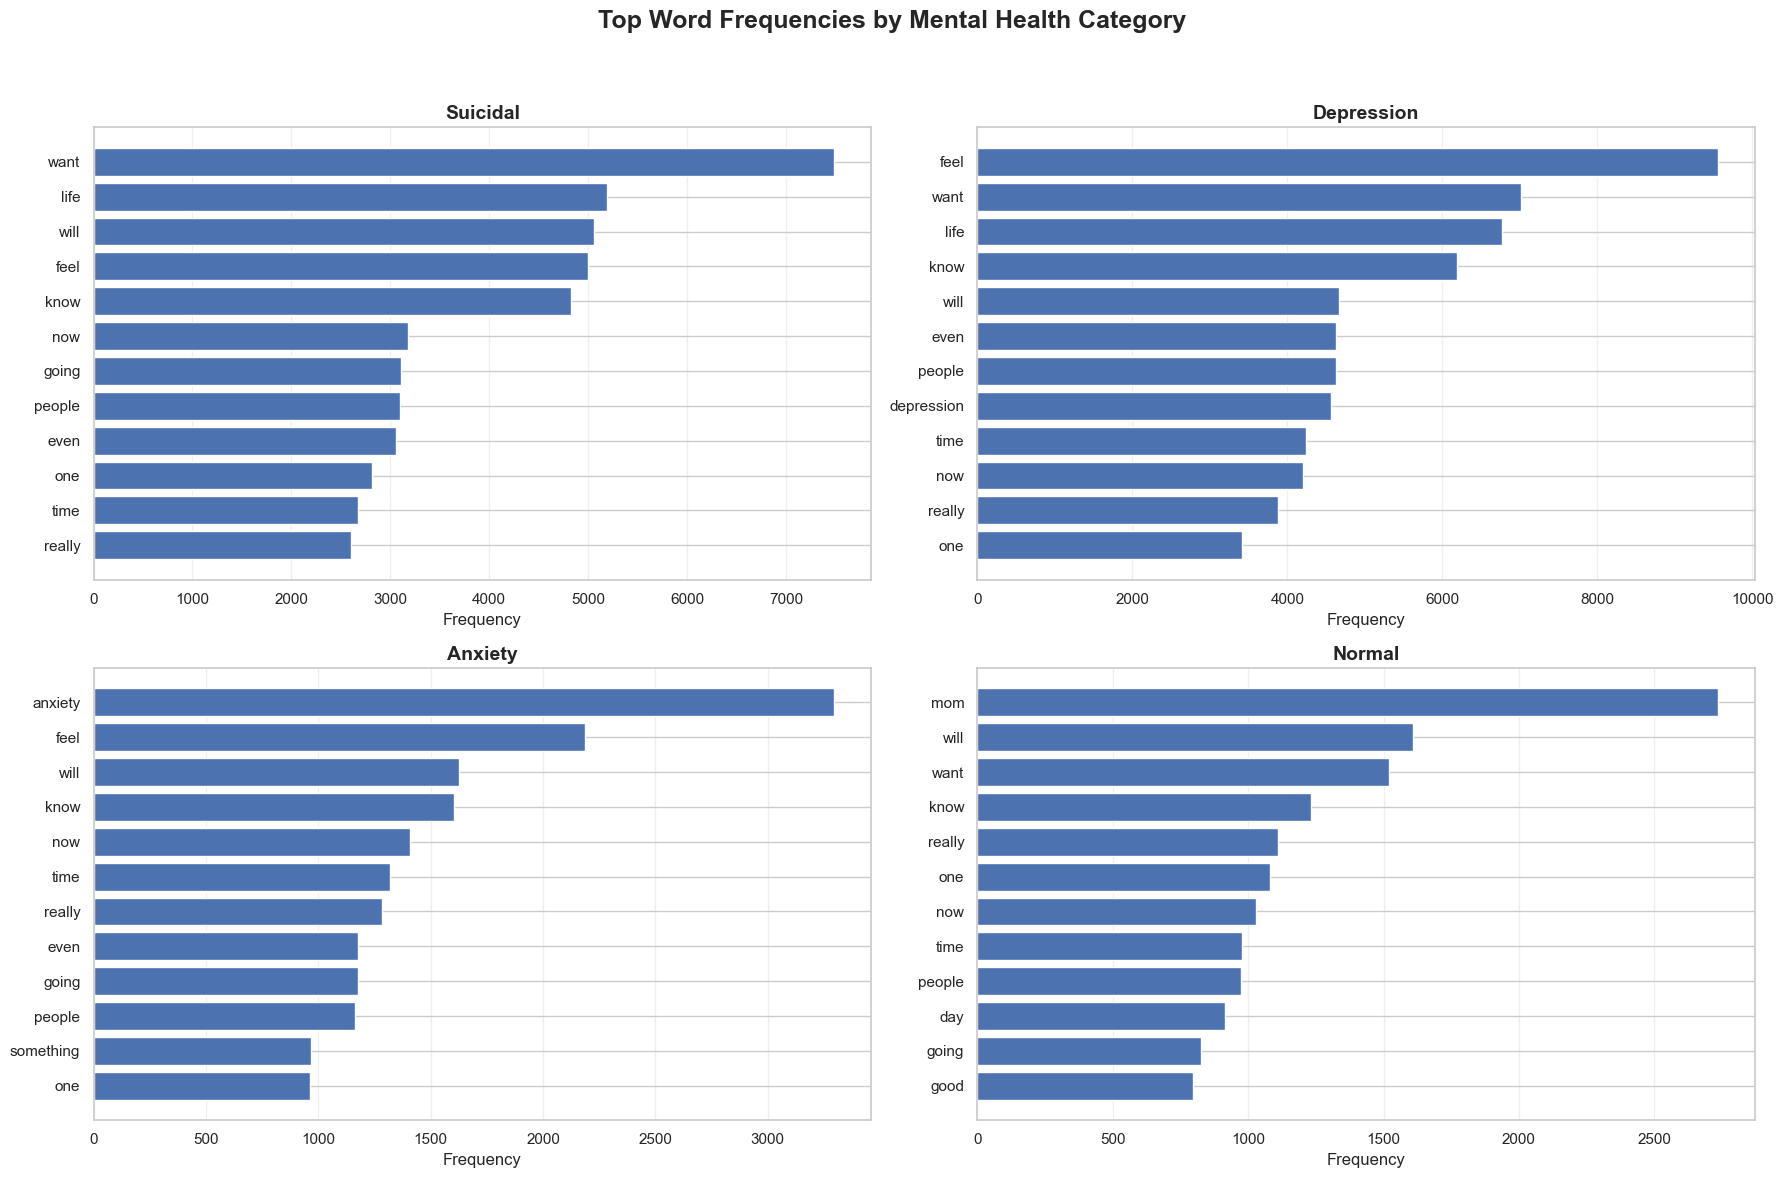

In [7]:
# Plot word frequency bar charts
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Top Word Frequencies by Mental Health Category", fontsize=18, fontweight="bold", y=0.98)

for ax, label in zip(axes.flatten(), labels_in_order):
    top_words = top_words_for_label(label, n=12)
    words = [w for w, c in top_words]
    freqs = [c for w, c in top_words]

    ax.barh(list(reversed(words)), list(reversed(freqs)))
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.set_xlabel("Frequency")
    ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Word clouds

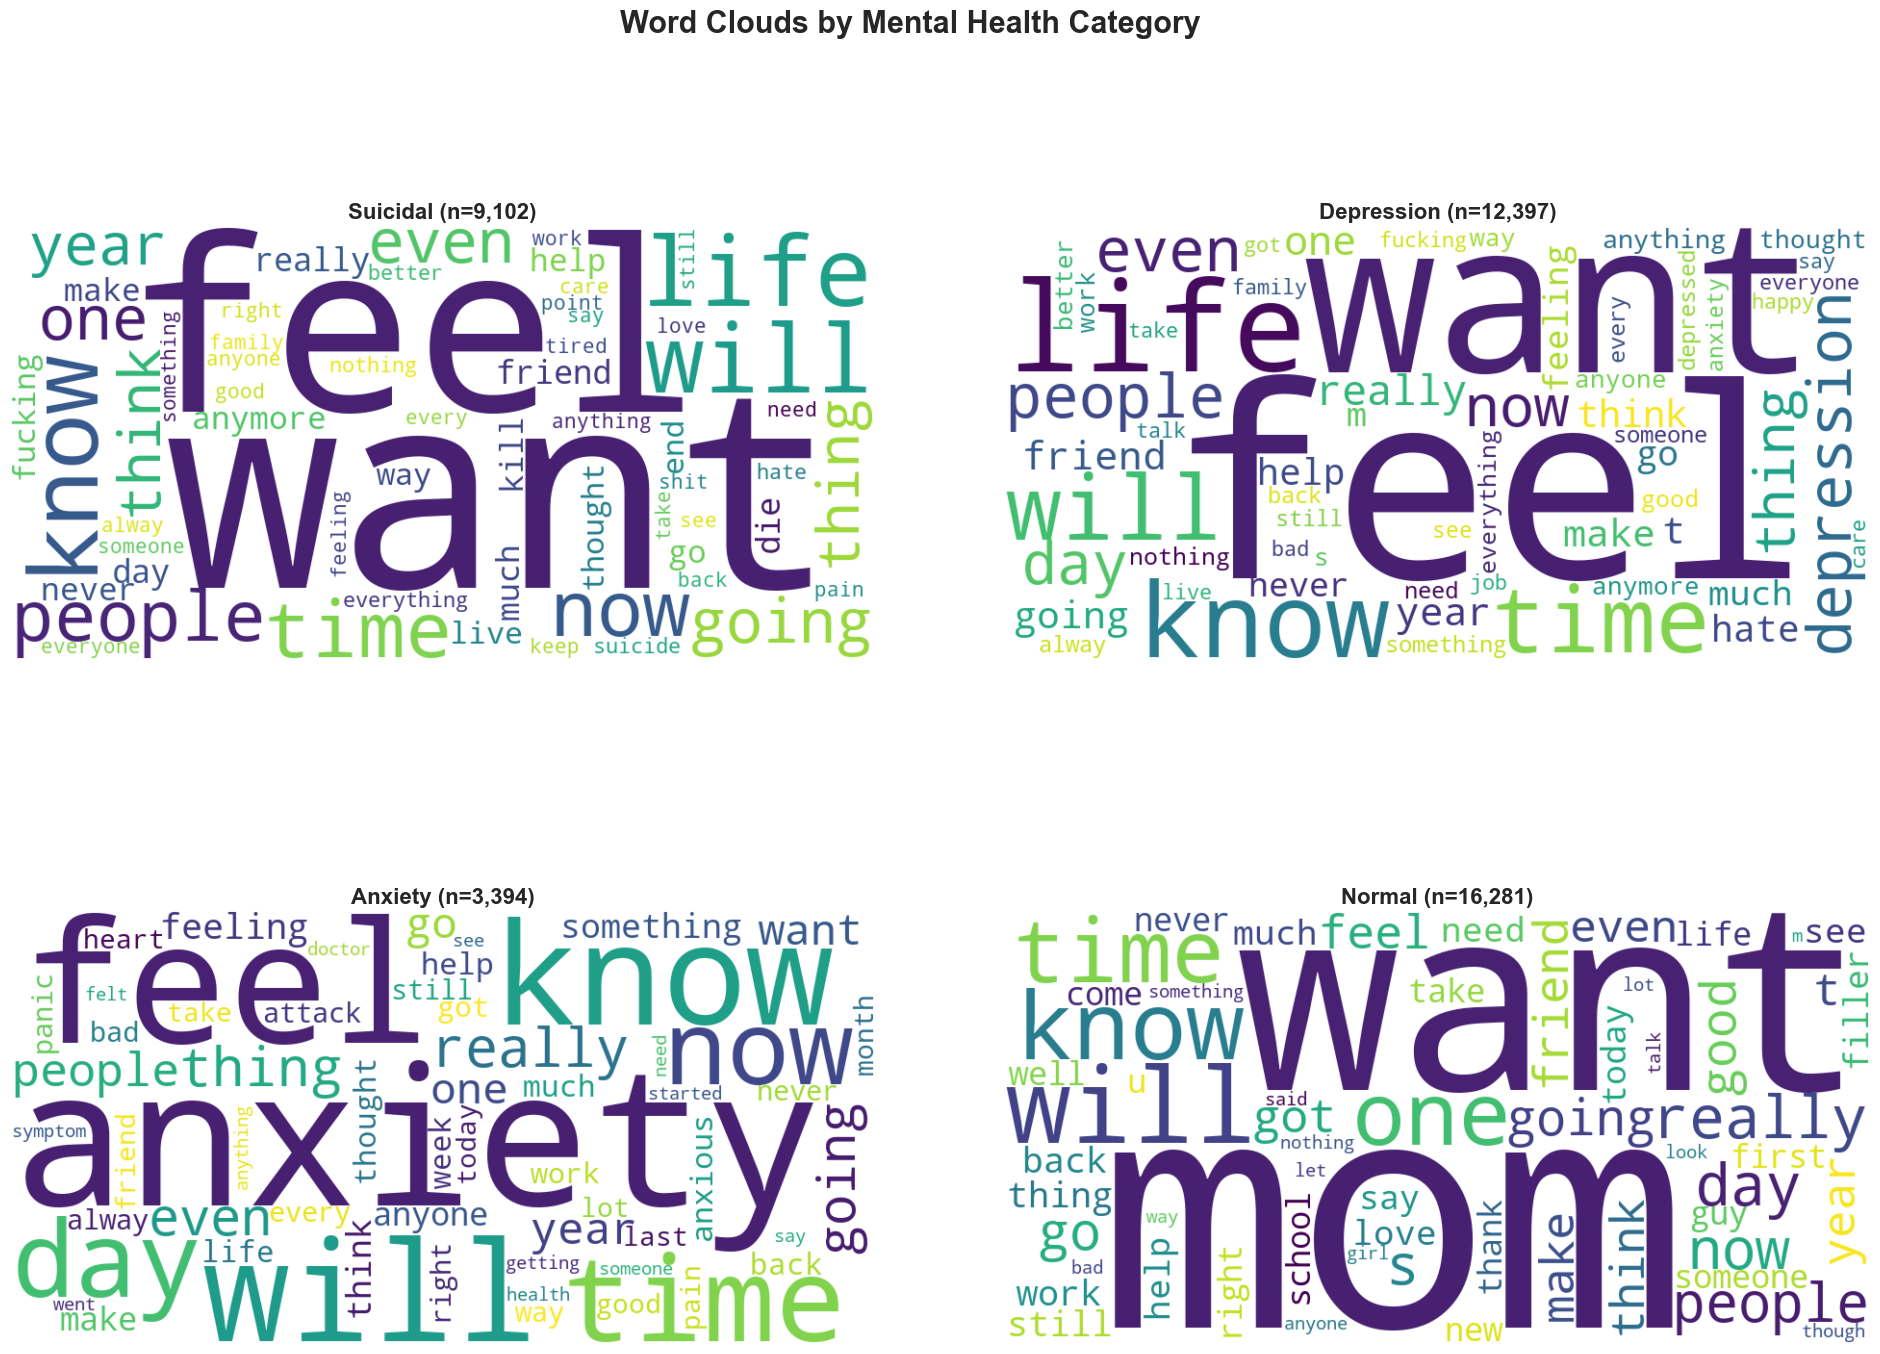

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
fig.suptitle("Word Clouds by Mental Health Category", fontsize=22, fontweight="bold", y=0.98)

for ax, label in zip(axes.flatten(), labels_in_order):
    # Combine all cleaned text for the current category
    text_blob = " ".join(df.loc[df["status"] == label, "clean_text"].tolist())

    # Generate word cloud
    wc = WordCloud(
        background_color="white",
        stopwords=stopwords,
        max_words=60,
        width=900,
        height=450,
        colormap="viridis",
        collocations=False,
        prefer_horizontal=0.9,
        random_state=42
    ).generate(text_blob)

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label} (n={counts.get(label, 0):,})", fontsize=16, fontweight="bold")
    ax.axis("off")

plt.subplots_adjust(hspace=0.25, wspace=0.15)
plt.show()

## 7. LDA topic modeling

LDA is an unsupervised learning method that identifies hidden themes in a collection of documents. It assumes that each document is a mixture of topics, and each topic is a mixture of words.

In [9]:
# Convert cleaned text into a document term matrix for LDA
lda_vectorizer = CountVectorizer(
    stop_words=list(stopwords),
    max_df=0.95,
    min_df=10
)

X_counts = lda_vectorizer.fit_transform(df["clean_text"])
feature_names = lda_vectorizer.get_feature_names_out()

print("Document-term matrix shape:", X_counts.shape)

c:\Users\Seyoung\Desktop\ML_cf_mentalhealth\Code\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


Document-term matrix shape: (41174, 7268)


In [10]:
# Train LDA
n_topics = 8

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda_model.fit(X_counts)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",8
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [11]:
def print_topics(model, feature_names, n_words=12):
    '''
    Print the top 12 words in each latent topic.
    '''
    # model.components_ contains the word distribution for each topic
    for topic_idx, topic in enumerate(model.components_):
        # sorts words by importance in the topic
        # takes the top 12 words
        # reverse the order so highest importance appears first
        top_idx = topic.argsort()[-n_words:][::-1]
        # since the model only knows word indices, this converts them back into actual words
        words = [feature_names[i] for i in top_idx]
        print(f"Topic {topic_idx + 1}: {', '.join(words)}")

print_topics(lda_model, feature_names, n_words=12)

Topic 1: one, people, new, will, us, good, make, know, money, post, see, work
Topic 2: help, need, please, want, amp, fuck, depression, someone, will, talk, know, mental
Topic 3: mom, feel, now, know, friends, time, really, even, want, years, year, school
Topic 4: anxiety, feel, now, know, feeling, depression, really, time, anyone, something, anxious, panic
Topic 5: day, sleep, night, will, morning, today, really, good, go, time, wa, now
Topic 6: life, people, feel, hate, know, even, want, think, really, one, person, someone
Topic 7: want, will, life, feel, know, die, going, anymore, fucking, even, nothing, tired
Topic 8: told, said, got, one, time, back, now, friend, went, years, never, today


In [12]:
# Compute topic proportions for each post
topic_distributions = lda_model.transform(X_counts)

# convert it to DataFrame
topic_cols = [f"Topic_{i+1}" for i in range(n_topics)]
topic_df = pd.DataFrame(topic_distributions, columns=topic_cols)
# attach category label
topic_df["status"] = df["status"].values

# average topic distribution by class
avg_topics_by_class = topic_df.groupby("status").mean()
display(avg_topics_by_class.round(3))

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8
status,,,,,,,,
Anxiety,0.060,0.041,0.083,0.459,0.111,0.100,0.069,0.078
Depression,0.047,0.072,0.165,0.126,0.058,0.248,0.204,0.081
Normal,0.182,0.123,0.085,0.066,0.255,0.089,0.083,0.117
Suicidal,0.041,0.074,0.112,0.049,0.043,0.178,0.400,0.102


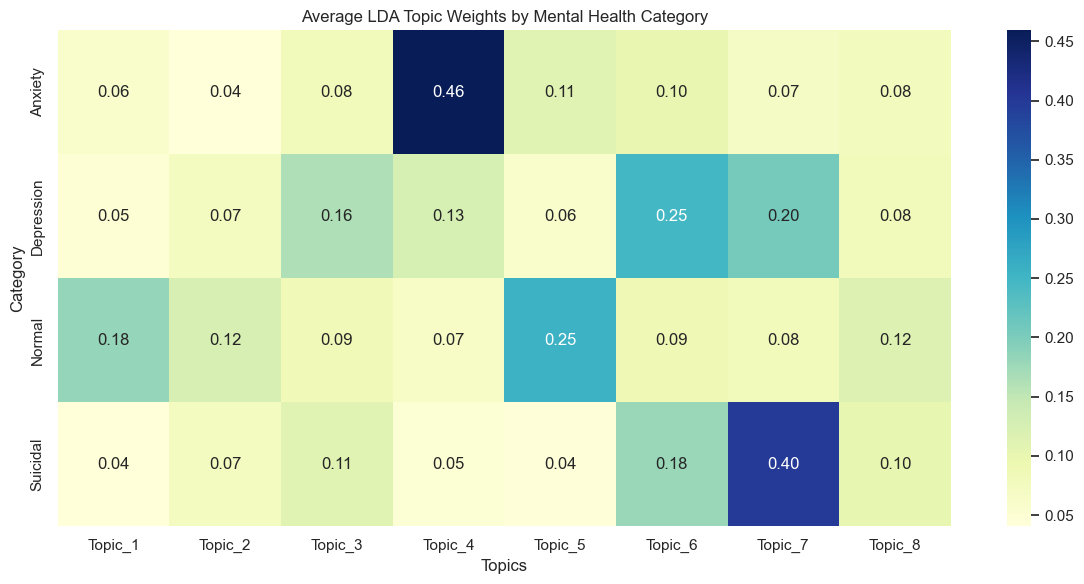

In [13]:
plt.figure(figsize=(12, 6))
sns.heatmap(avg_topics_by_class, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Average LDA Topic Weights by Mental Health Category")
plt.xlabel("Topics")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 8. Sentence embeddings for data visualization

In [14]:
# To keep runtime manageable, we take a balanced sample from each class before visualizing embeddings
sample_n_per_class = 500

df_sample = (
    df.groupby("status", group_keys=False)
      .sample(n=sample_n_per_class, random_state=42)
      .reset_index(drop=True)
)

print(df_sample["status"].value_counts())

status
Anxiety       500
Depression    500
Normal        500
Suicidal      500
Name: count, dtype: int64


In [15]:
# Load pretrained embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert sampled cleaned text into embeddings
sample_embeddings = embedding_model.encode(
    df_sample["clean_text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

print("Embedding shape:", sample_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


## 9. t-SNE visualization

In [ ]:
# sentence embeddings have a very high dimensionality -> t-SNE reduces them to 2 dimensions.
tsne = TSNE(
    n_components=2, # reduce data to 2 dimensions
    perplexity=30, # approximate neighborhood size
    random_state=42,
    init="pca", # optimization with pca
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(sample_embeddings)

# attach 2D coordinates with labels
tsne_df = pd.DataFrame({
    "x": X_tsne[:, 0],
    "y": X_tsne[:, 1],
    "status": df_sample["status"].values
})

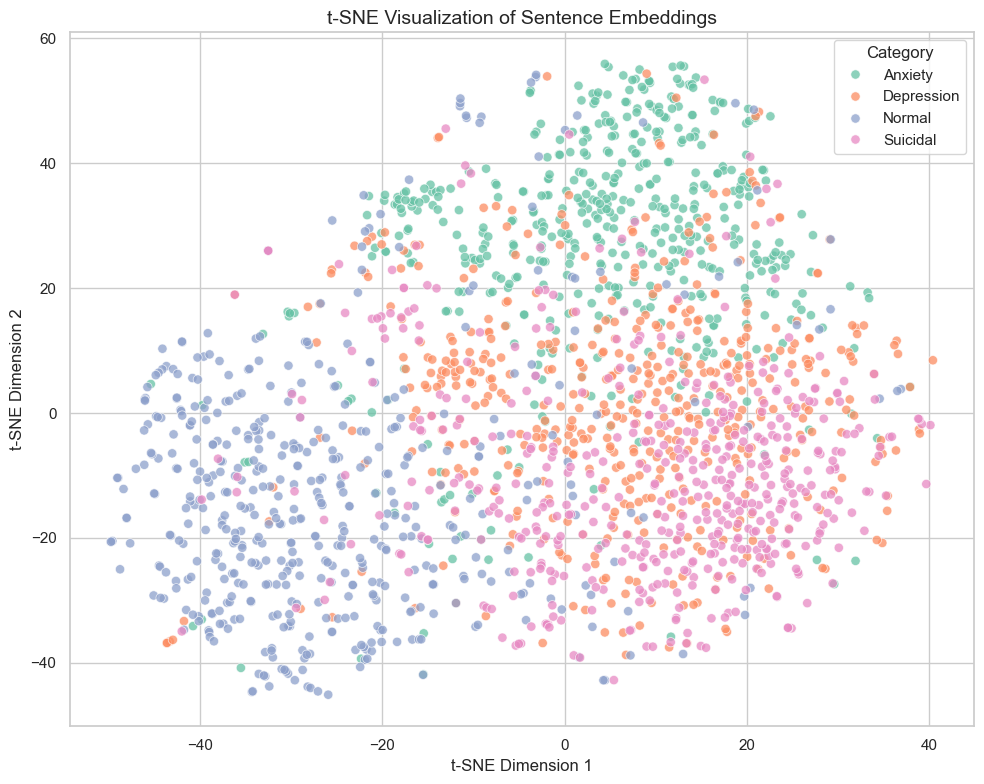

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=tsne_df,
    x="x",
    y="y",
    hue="status",
    palette="Set2",
    alpha=0.75,
    s=45
)

plt.title("t-SNE Visualization of Sentence Embeddings", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

## 10. UMAP visualization

In [ ]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1, # how tightly clusters form
    random_state=42
)

X_umap = umap_reducer.fit_transform(sample_embeddings)

umap_df = pd.DataFrame({
    "x": X_umap[:, 0],
    "y": X_umap[:, 1],
    "status": df_sample["status"].values
})

C:\Users\Seyoung\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


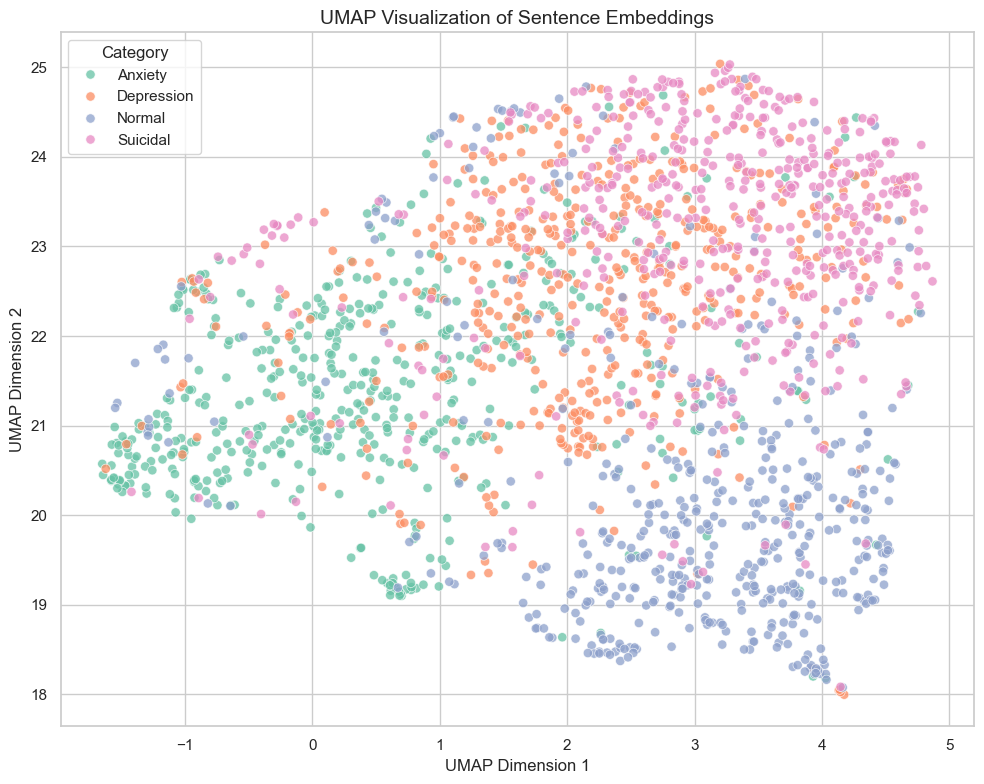

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x="x",
    y="y",
    hue="status",
    palette="Set2",
    alpha=0.75,
    s=45
)

plt.title("UMAP Visualization of Sentence Embeddings", fontsize=14)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Category")
plt.tight_layout()
plt.show()